In [48]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)
print("Running on:", DEVICE)

Running on: cuda


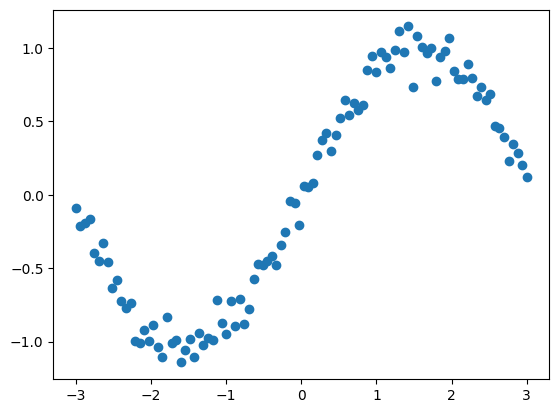

[np.float64(0.9032945639381899), np.float64(0.302438028591318), np.float64(0.21186231534876973), np.float64(0.1981220033943185), np.float64(0.19598232605594412), np.float64(0.19561404495578089), np.float64(0.19552896236574963), np.float64(0.19549716987611648), np.float64(0.19548023193407446), np.float64(0.1954699045728726), np.float64(0.19546337223075047), np.float64(0.1954592031418718), np.float64(0.1954565366717254), np.float64(0.19545483039362807), np.float64(0.19545373841518343), np.float64(0.19545303955492738), np.float64(0.19545259228525844), np.float64(0.19545230603280492), np.float64(0.1954521228312549), np.float64(0.195452005582266), np.float64(0.19545193054291357), np.float64(0.19545188251772802), np.float64(0.19545185178160931), np.float64(0.19545183211049338), np.float64(0.1954518195209791), np.float64(0.19545181146369003), np.float64(0.19545180630702497), np.float64(0.19545180300675935), np.float64(0.19545180089458938), np.float64(0.1954517995428006), np.float64(0.19545179

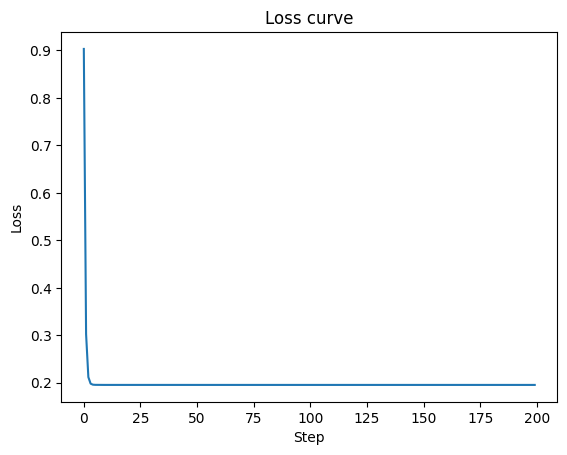

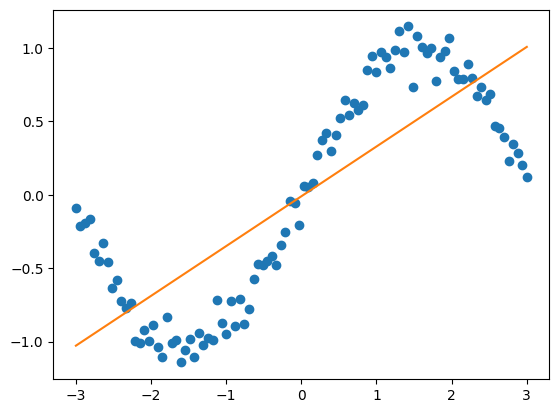

In [49]:
# TODO: Generate the toy data
x = np.linspace(-3, 3, 100) 
y = np.sin(x) + np.random.normal(scale = 0.1, size=100)  #small Gaussian noise (std=0.1)
plt.plot(x, y, 'o', label='toy data')
#   Plot it.
plt.show()

# TODO: Initialise w and b to small random values. 
w = np.random.normal(scale = 0.1)
b = np.random.normal(scale = 0.1)
#print(w)
#print(b)
# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
lr= 0.1
#   Record the loss at every step.
losses = []
for i in range(200):
    y_hat = w * x + b
    loss  = np.mean((y_hat - y) ** 2)    
    #print(loss)           # MSE
    dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
    db    = np.mean(2 * (y_hat - y))                # dLoss/db
    w    -= lr * dw
    b    -= lr * db
    losses.append(loss)
print(losses)

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
plt.plot(losses)
plt.title("Loss curve")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

plt.plot(x, y, 'o')
plt.plot(x, y_hat, label='fitted line')
plt.show()
     

In [50]:
""" Student Reasoning — The single neuron 1. Derive dLoss/dw on paper and include a photo or the LaTeX in this 
cell — does it match the code? 2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, 
and WHY can a single neuron never fit a sine wave, no matter how long you train?"""

' Student Reasoning — The single neuron 1. Derive dLoss/dw on paper and include a photo or the LaTeX in this \ncell — does it match the code? 2. The loss stops improving but the fit is clearly bad. Is this underfitting or overfitting, \nand WHY can a single neuron never fit a sine wave, no matter how long you train?'

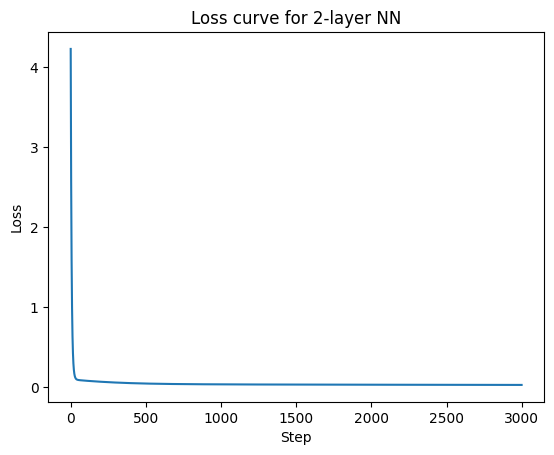

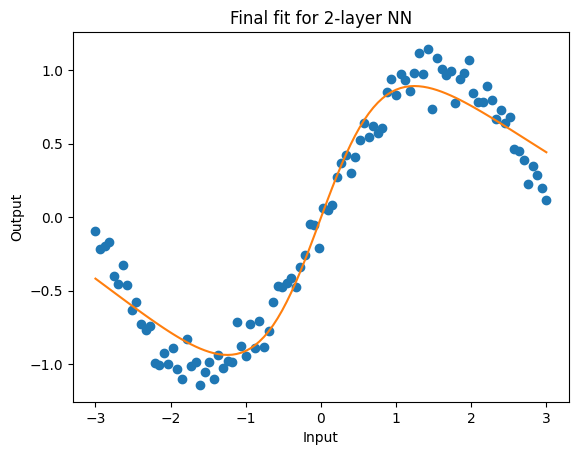

In [51]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)
x = x.reshape(-1, 1) 
y = y.reshape(-1, 1) 
W1 = np.random.randn(1, 8) * 0.5
b1 = np.random.randn(8) * 0.5
W2 = np.random.randn(8, 1) * 0.5
b2 = np.random.randn(1) * 0.5


# TODO: Forward pass (keep the intermediate values — you need them for backprop):
lr2 = 0.01
losses2 = []
for a in range(3000):
    # Forward pass
    z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
    h  = np.tanh(z1)        # activation
    y_hat2 = h @ W2 + b2     # output, shape (100, 1)
    loss2  = np.mean((y_hat2 - y) ** 2)
    

    # TODO: Backward pass (the chain rule, layer by layer):
    d_yhat = 2 * (y_hat2 - y) / len(y)
    dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
    dh  = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
    dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

    # TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
    #   record the loss.
    losses2.append(loss2)
    # Update parameters
    W2 -= lr2 * dW2
    b2 -= lr2 * db2
    W1 -= lr2 * dW1
    b1 -= lr2 * db1

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?
plt.plot(losses2)
plt.title("Loss curve for 2-layer NN")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.show()

plt.plot(x, y, 'o')
plt.plot(x, y_hat2)
plt.title("Final fit for 2-layer NN")
plt.xlabel("Input")
plt.ylabel("Output")
plt.show()

In [52]:
"""Student Reasoning — Depth and activations 1. With tanh removed, the deep network fits no better than the single 
neuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer. 
2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.) 
3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?"""

"Student Reasoning — Depth and activations 1. With tanh removed, the deep network fits no better than the single \nneuron of Part 1.1. Explain mathematically why a stack of linear layers collapses into one linear layer. \n2. What role did the hidden layer's 8 neurons play in fitting the curve? (Hint: plot a few columns of h against x.) \n3. This is exactly what loss.backward() will automate in Section 2. In one sentence, what is backpropagation?"

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:127: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/tmp/ipykernel_961/874346270.py:20: RuntimeWarning: overflow encountered in square
  loss2  = np.mean((y_hat2 - y) ** 2)
/tmp/ipykernel_961/874346270.py:25: RuntimeWarning: overflow encountered in matmul
  dh  = d_yhat @ W2.T
/tmp/ipykernel_961/874346270.py:26: RuntimeWarning: invalid value encountered in multiply
  dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
/usr/local/lib/python3.12/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


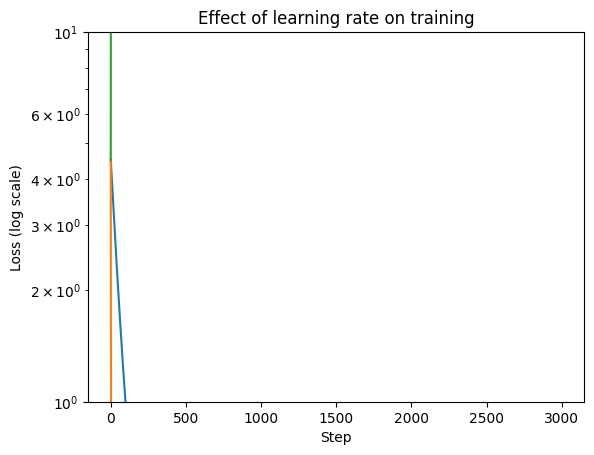

In [53]:
# TODO: Wrap your Part 1.2 training loop in a function train_toy(lr, steps=3000)
#   that returns the list of losses.

x = x.reshape(-1, 1) 
y = y.reshape(-1, 1) 
def train_toy(lr, steps=3000):
    np.random.seed(RANDOM_STATE)
    # Initialize parameters
    W1 = np.random.randn(1, 8) * 0.5
    b1 = np.random.randn(8) * 0.5
    W2 = np.random.randn(8, 1) * 0.5
    b2 = np.random.randn(1) * 0.5

    losses = []
    for a in range(steps):
        # Forward pass
        z1 = x @ W1 + b1        
        h  = np.tanh(z1)       
        y_hat2 = h @ W2 + b2     
        loss2  = np.mean((y_hat2 - y) ** 2)
        
        # Backward pass
        d_yhat = 2 * (y_hat2 - y) / len(y)
        dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
        dh  = d_yhat @ W2.T
        dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
        dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

        # Update parameters
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        losses.append(loss2)

    return losses

# TODO: Run it with THREE learning rates, e.g. lr = 0.001, 0.05, 1.0
#   (keep the same initial weights for a fair comparison — reset the seed).
losses_1  = train_toy(lr=0.001)
losses_2  = train_toy(lr=0.05)
losses_3 = train_toy(lr=1.0)

# TODO: Plot the three loss curves on the same axes (log scale on y helps), with a legend
plt.plot(losses_1, label='lr = 0.001')
plt.plot(losses_2, label='lr = 0.05')
plt.plot(losses_3, label='lr = 1.0')
plt.yscale('log')
plt.xlabel('Step')
plt.ylabel('Loss (log scale)')
plt.title('Effect of learning rate on training')

plt.show()

In [54]:
"""Student Reasoning — Learning rate Describe what each of the three curves shows. Why does a too-large learning rate make 
the loss explode or oscillate instead of just "learning faster"?"""

'Student Reasoning — Learning rate Describe what each of the three curves shows. Why does a too-large learning rate make \nthe loss explode or oscillate instead of just "learning faster"?'

In [55]:

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TODO: Load the obesity dataset (same OBESITY_URL as Lab 2).

OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"
obesity = pd.read_csv(OBESITY_URL)
print(obesity.shape)
print()
print(obesity.head())
print()
obesity.info()
print()
print(obesity.describe())
print()
print(obesity.isna().sum())
print()


# TODO: Encode categoricals exactly as you did in Lab 2
#   (binary yes/no -> 0/1; Gender/MTRANS/CAEC/CALC -> your justified choice).
#   Encode the target NObeyesdad into integers 0..6 (LabelEncoder) — CrossEntropyLoss
#   expects integer class indices.

binary_columns = ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]
for col in binary_columns:
    obesity[col] = obesity[col].map({"yes": 1, "no": 0})

obesity["Gender"] = obesity["Gender"].map({"Male": 1, "Female": 0})

caec = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
calc = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}

obesity["CAEC"] = obesity["CAEC"].map(caec)
obesity["CALC"] = obesity["CALC"].map(calc)

obesity = pd.get_dummies(obesity, columns=["MTRANS"], drop_first=True)

mtrans = ["MTRANS_Bike", "MTRANS_Motorbike", "MTRANS_Public_Transportation", "MTRANS_Walking"]
obesity[mtrans] = obesity[mtrans].astype(int)

label = LabelEncoder()
obesity["NObeyesdad_encoded"] = label.fit_transform(obesity["NObeyesdad"])

obesity["BMI"] = obesity["Weight"] / (obesity["Height"] ** 2)

# TODO: Stratified train / validation / test split (60/20/20, stratify=y,
#   random_state=RANDOM_STATE).

X_ob = obesity.drop(columns=["NObeyesdad", "NObeyesdad_encoded"])
y_ob = obesity["NObeyesdad_encoded"]

X_ob_remain, X_ob_test, y_ob_remain, y_ob_test = train_test_split(
    X_ob, y_ob, test_size=0.20, random_state=RANDOM_STATE, stratify=y_ob)

X_ob_train, X_ob_val, y_ob_train, y_ob_val = train_test_split(
    X_ob_remain, y_ob_remain, test_size=0.25, random_state=RANDOM_STATE, stratify=y_ob_remain)

# TODO: Fit a StandardScaler on the TRAINING set only; transform all three splits.
#   (Neural networks are far more sensitive to feature scale than random forests — 
#    remember Section 1, where all gradients depended on x!)

ob_scaler = StandardScaler()
numeric_ob = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE", "BMI"]
X_ob_train[numeric_ob] = ob_scaler.fit_transform(X_ob_train[numeric_ob])
X_ob_val[numeric_ob] = ob_scaler.transform(X_ob_val[numeric_ob])
X_ob_test[numeric_ob] = ob_scaler.transform(X_ob_test[numeric_ob])



# TODO: Convert to tensors and wrap in DataLoaders:
#   X -> torch.float32, y -> torch.long
#   train_loader (batch_size=32, shuffle=True), val_loader, test_loader
x_ob_train_tensor = torch.tensor(X_ob_train.values, dtype=torch.float32)
y_ob_train_tensor = torch.tensor(y_ob_train.values, dtype=torch.long)
train_dataset = torch.utils.data.TensorDataset(x_ob_train_tensor, y_ob_train_tensor)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)

x_ob_val_tensor = torch.tensor(X_ob_val.values, dtype=torch.float32)
y_ob_val_tensor = torch.tensor(y_ob_val.values, dtype=torch.long)
val_dataset = torch.utils.data.TensorDataset(x_ob_val_tensor, y_ob_val_tensor)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=32, shuffle=False)

x_ob_test_tensor = torch.tensor(X_ob_test.values, dtype=torch.float32)
y_ob_test_tensor = torch.tensor(y_ob_test.values, dtype=torch.long)
test_dataset = torch.utils.data.TensorDataset(x_ob_test_tensor, y_ob_test_tensor)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)



(2111, 17)

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transporta

In [56]:
"""Student Reasoning — Preprocessing for neural networks 1. Why does CrossEntropyLoss need integer class labels rather 
than one-hot vectors in PyTorch? 2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks 
care so much? Connect your answer to the gradient formulas you wrote in Section 1. 3. What does shuffle=True on the training 
DataLoader do, and why does it help?"""


'Student Reasoning — Preprocessing for neural networks 1. Why does CrossEntropyLoss need integer class labels rather \nthan one-hot vectors in PyTorch? 2. A random forest in Lab 2 did not care about feature scaling. Why do neural networks \ncare so much? Connect your answer to the gradient formulas you wrote in Section 1. 3. What does shuffle=True on the training \nDataLoader do, and why does it help?'

In [57]:
# TODO: Define a FeedForwardNet class (subclass nn.Module) with:
#   - constructor args: input_dim, hidden_sizes=(64, 32), n_classes=7
#   - at least TWO hidden layers with ReLU activations
#   - output layer producing 7 raw logits
#     (NO softmax — nn.CrossEntropyLoss applies log-softmax internally)

class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], n_classes)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x    

# TODO: Instantiate, move to DEVICE, print the model.
input_dim = X_ob_train.shape[1]

model = FeedForwardNet(input_dim=input_dim, hidden_sizes=(64, 32), n_classes=7)
model = model.to(DEVICE)
print(model)

# TODO: Count trainable parameters:
#   sum(p.numel() for p in model.parameters() if p.requires_grad)
#   Verify the count for the FIRST layer by hand: input_dim * 64 + 64.
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Number of trainable parameters: {num_params}")


FeedForwardNet(
  (fc1): Linear(in_features=20, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=7, bias=True)
  (relu): ReLU()
)
Number of trainable parameters: 3655


In [58]:
"""Student Reasoning — Architecture 1. Show the by-hand parameter count for every layer and confirm it matches PyTorch. 2. Why ReLU here instead 
of the tanh you used in Section 1? Name one advantage. 3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2."""

'Student Reasoning — Architecture 1. Show the by-hand parameter count for every layer and confirm it matches PyTorch. 2. Why ReLU here instead \nof the tanh you used in Section 1? Name one advantage. 3. What would the network compute if you removed the ReLUs? (You proved this in Part 1.2.'

Train Loss: 0.03372858434449881
Train Accuracy: 99.44707740916272
Validation Loss: 0.1501369835542781
Validation Accuracy: 94.7867298578199


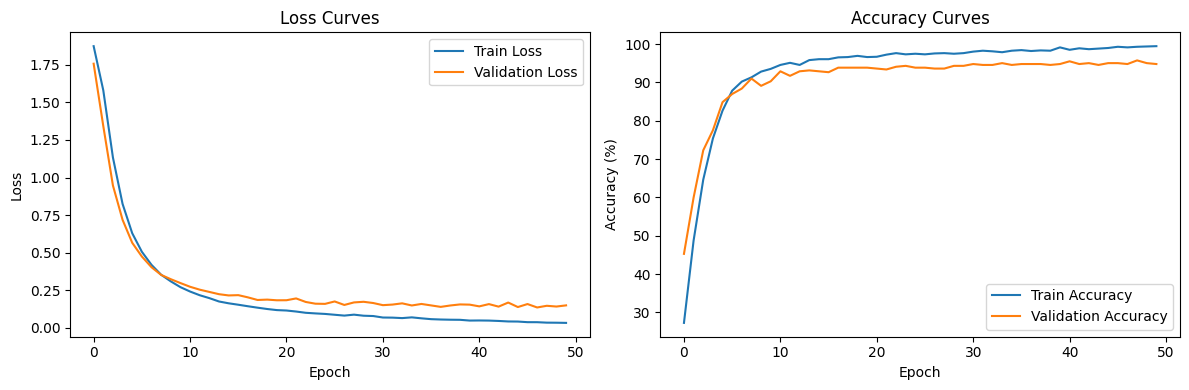

In [59]:
# TODO: 
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)   # or SGD — justify

# TODO: Train for at least 50 epochs. Each epoch:
train_losses = []
val_losses = []
train_accuracy = []
val_accuracy = []
best_val_accuracy = 0.0
n_epochs = 50

for epoch in range(n_epochs):
    model.train(); 
    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        logits = model(xb.to(DEVICE))
        loss = criterion(logits, yb.to(DEVICE))
        loss.backward()          # <- the backprop you wrote by hand in Part 1.2
        optimizer.step()         # <- the update rule you wrote in Part 1.1

        running_train_loss += loss.item()
        _,predicted = torch.max(logits.data, 1)
        total_train += yb.size(0)
        correct_train += (predicted == yb.to(DEVICE)).sum().item()

    train_losses.append(running_train_loss / len(train_loader))
    train_accuracy.append(100. * correct_train / total_train)

    model.eval() 
    running_val_loss = 0.0
    correct_val = 0
    total_val = 0
    with torch.no_grad(): 
        for xb, yb in val_loader:
            logits = model(xb.to(DEVICE))
            loss = criterion(logits, yb.to(DEVICE))

            running_val_loss += loss.item()
            _, predicted = torch.max(logits.data, 1)
            total_val += yb.size(0)
            correct_val += (predicted == yb.to(DEVICE)).sum().item()

    val_losses.append(running_val_loss / len(val_loader))
    val_accuracy.append(100. * correct_val / total_val)

    
# TODO: Save the best model (highest validation accuracy):
if val_accuracy[-1] > best_val_accuracy:
        best_val_accuracy = val_accuracy[-1]
        torch.save(model.state_dict(), "ffn_best.pt")

print("Train Loss:", train_losses[-1])
print("Train Accuracy:", train_accuracy[-1])
print("Validation Loss:", val_losses[-1])
print("Validation Accuracy:", val_accuracy[-1]      )

# TODO: Plot loss curves (train + val) and accuracy curves (train + val), with legends.

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curves")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_accuracy, label="Train Accuracy")
plt.plot(val_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy Curves")
plt.legend()

plt.tight_layout()
plt.show()

In [60]:
"""Student Reasoning — Training 1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is the forward pass, 
which computes gradients, which is the update rule? 2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the 
specific numbers that back up your claim. 3. Why do we call optimizer.zero_grad() every batch? What silently goes wrong without it?"""

'Student Reasoning — Training 1. Map each line of the PyTorch loop to the NumPy code you wrote in Section 1: which line is the forward pass, \nwhich computes gradients, which is the update rule? 2. Looking at your curves, is the model overfitting, underfitting, or well-fitted? Quote the \nspecific numbers that back up your claim. 3. Why do we call optimizer.zero_grad() every batch? What silently goes wrong without it?'

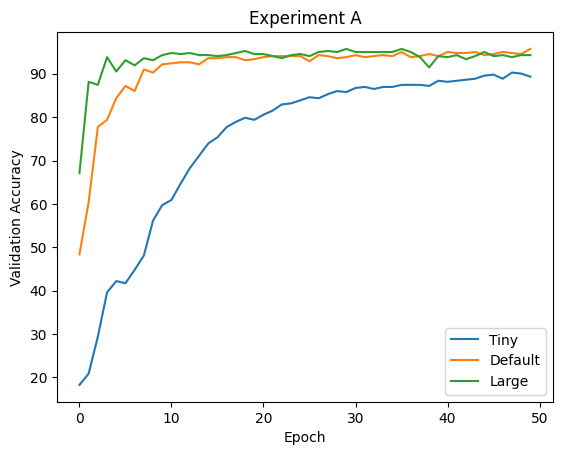

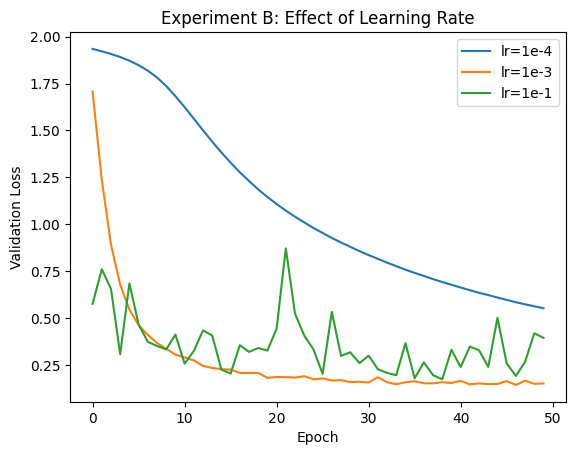

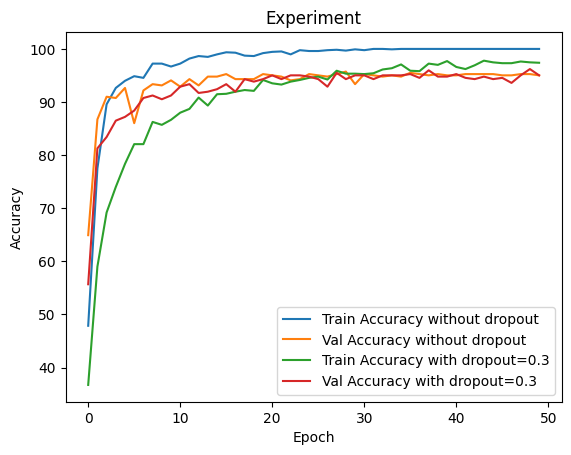

In [62]:
# Wrap your Part 2.3 loop in a function first:
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_sizes=(64, 32), n_classes=7, dropout=0.0):
        super().__init__()
        layers = []
        prev_size = input_dim

        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(nn.ReLU())
            if dropout > 0.0:
                layers.append(nn.Dropout(dropout))
            prev_size = h

        layers.append(nn.Linear(prev_size, n_classes))

        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)
    
def run_experiment(hidden_sizes=(64, 32), lr=1e-3, batch_size=32, epochs=50, dropout=0.0):

    train_ds = TensorDataset(x_ob_train_tensor, y_ob_train_tensor)
    val_ds = TensorDataset(x_ob_val_tensor, y_ob_val_tensor)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # Fresh model, criterion, optimizer
    input_dim = x_ob_train_tensor.shape[1]
    model = FeedForwardNet(input_dim=input_dim, hidden_sizes=hidden_sizes, n_classes=7, dropout=dropout)
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {"train_losses": [], "val_losses": [],
        "train_accuracy": [], "val_accuracy": []}
    
    for epoch in range(n_epochs):
        model.train(); 
        running_train_loss = 0.0
        correct_train = 0
        total_train = 0

        for xb, yb in train_loader:
            optimizer.zero_grad()
            logits = model(xb.to(DEVICE))
            loss = criterion(logits, yb.to(DEVICE))
            loss.backward()          
            optimizer.step()         

            running_train_loss += loss.item()
            _,predicted = torch.max(logits.data, 1)
            total_train += yb.size(0)
            correct_train += (predicted == yb.to(DEVICE)).sum().item()

        history["train_losses"].append(running_train_loss / len(train_loader))
        history["train_accuracy"].append(100. * correct_train / total_train)

        model.eval() 
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0
        with torch.no_grad(): 
            for xb, yb in val_loader:
                logits = model(xb.to(DEVICE))
                loss = criterion(logits, yb.to(DEVICE))

                running_val_loss += loss.item()
                _, predicted = torch.max(logits.data, 1)
                total_val += yb.size(0)
                correct_val += (predicted == yb.to(DEVICE)).sum().item()

        history["val_losses"].append(running_val_loss / len(val_loader))
        history["val_accuracy"].append(100. * correct_val / total_val)
    return history

# TODO — Experiment A (capacity): tiny (8,) vs default (64, 32) vs large (256, 128, 64).
#   Plot the three validation-accuracy curves together.

tiny = run_experiment(hidden_sizes=(8,))
default = run_experiment(hidden_sizes=(64, 32))
large = run_experiment(hidden_sizes=(256, 128, 64))

plt.plot(tiny["val_accuracy"], label="Tiny")
plt.plot(default["val_accuracy"], label="Default")
plt.plot(large["val_accuracy"], label="Large")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Experiment A")
plt.legend()
plt.show()

# TODO — Experiment B (learning rate): lr = 1e-4, 1e-3, 1e-1 (same architecture).
#   Plot the three validation-loss curves together. Compare with Part 1.3.

hlow = run_experiment(lr=1e-4)
medium = run_experiment(lr=1e-3)
high = run_experiment(lr=1e-1)

plt.plot(hlow["val_losses"], label="lr=1e-4")
plt.plot(medium["val_losses"], label="lr=1e-3")
plt.plot(high["val_losses"], label="lr=1e-1")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Experiment B: Effect of Learning Rate")
plt.legend()
plt.show()

# TODO — Experiment C (regularization): take your LARGEST network and train it
#   with and without nn.Dropout(0.3) after each hidden layer.
#   Plot train vs validation accuracy for both runs.

with_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.3)
without_dropout = run_experiment(hidden_sizes=(256, 128, 64), dropout=0.0)

plt.plot(without_dropout["train_accuracy"], label="Train Accuracy without dropout")
plt.plot(without_dropout["val_accuracy"], label="Val Accuracy without dropout")
plt.plot(with_dropout["train_accuracy"], label="Train Accuracy with dropout=0.3")
plt.plot(with_dropout["val_accuracy"], label="Val Accuracy with dropout=0.3")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Experiment")
plt.legend()
plt.show()